##**Imports**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##**Mount Drive and Load Data**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load in data
fpath = "/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week06/Data/insurance.csv"
df = pd.read_csv(fpath)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#**Define Existing plot_categorical_vs_target Function**

In [ ]:
# Previously defined function
def plot_categorical_vs_target(df, x, y='SalePrice',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

/tmp/ipykernel_3419/3674886926.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


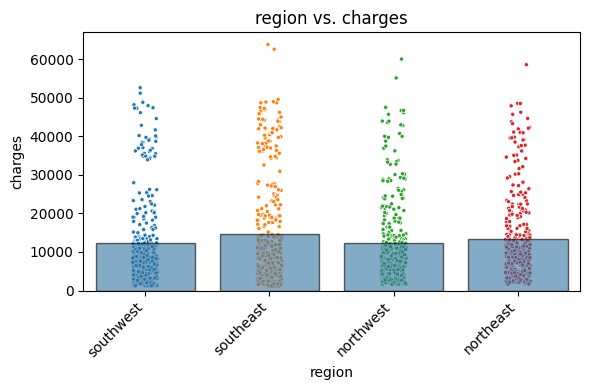

In [ ]:
# Call function to explore region when charges is the target
plot_categorical_vs_target(df,'region', 'charges');

In [ ]:
# Replacing int target with string labels
target_map = {1:"Smoker", 0:'Non-Smoker'}
df['smoker'] = df['smoker'].replace(target_map)
df['smoker'].value_counts(dropna=False)

,count
smoker,
no,1064
yes,274


🔥 شو عمل؟

✔️ استخدم Seaborn plot

✔️ حط hue='smoker'

👉 يعني كل فئة لون مختلف (Yes / No)


✔️ استخدم stat='percent'

👉 بدل العدد → يعرض النسبة %

✔️ استخدم multiple='fill'

👉 يخلي كل عمود = 100%

👉 ويبين توزيع الفئات داخل كل category

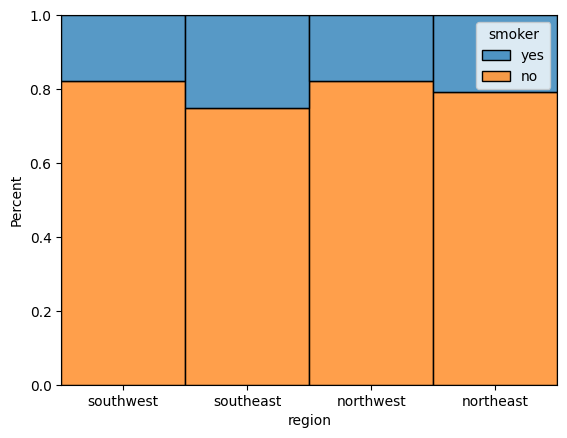

In [ ]:
# Comparing categorical feature with categorical target
ax = sns.histplot(data=df, hue='smoker', x='region', stat='percent',
                  multiple='fill')

**One function → works for both regression & classification using if conditions**

In [ ]:
# Updating function
def plot_categorical_vs_target(df, x, y, figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None, target_type='reg'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)
  # REGRESSION-TARGET PLOT
  if target_type=='reg': #Added if statement here
    # Barplot
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None)
    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                  order=order, hue_order=order, legend=False,
                  edgecolor='white', linewidth=0.5,
                  size=3,zorder=0)
  # CLASSIFICATION-TARGET PLOT # This is the new code for the classification task
  elif target_type=='class':
    ax = sns.histplot(data=temp_df, hue=y, x=x, stat='percent',  multiple='fill')
  # Rotate xlabels
  ax.set_xticks(ax.get_xticks()) # Added this to prevent a bug
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

#**Testing a Regression Task**

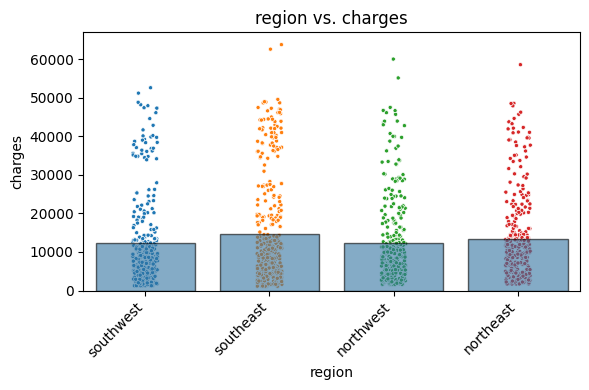

In [ ]:
# testing the default regression version
plot_categorical_vs_target(df, 'region','charges');

#**Testing a Classification Task**

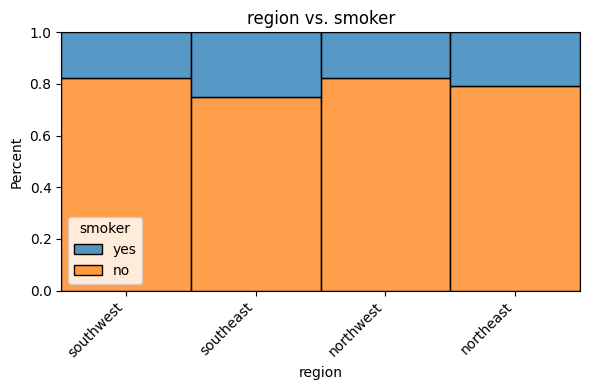

In [ ]:
# testing the classification version
plot_categorical_vs_target(df, 'region', 'smoker', target_type='class');